# Genomics-informed ecophysiological modeling in plants (Wang et al. 2019) — minimal reproduction

**Paper:** Wang, Guadagno, Mao, Mackay, Pleban, Baker, Weinig, Jannink, Ewers.
*A framework for genomics-informed ecophysiological modeling in plants.*
Journal of Experimental Botany 70(9):2561–2574 (2019). doi:[10.1093/jxb/erz090](https://doi.org/10.1093/jxb/erz090) — PMC6487588.

**Author code:** [DRWang3/leaf_model_TREES_paper](https://github.com/DRWang3/leaf_model_TREES_paper) @ commit `7646604d27bbc50a614a4176c4668d43be812b84`

**Scope of this notebook (minimal reproduction):**
1. Refit genotype-specific logistic leaf-growth parameters (**K**, **N0**, **r**) per morphotype (CC, VT, R500) from the deposited non-stressed leaf-area CSV, using the authors' hierarchical Bayesian model (2-level) with a reduced-but-documented MCMC budget (the authors used rjags with 7500 adapt/burn-in, thin 50, 1000 saved samples; we keep the same model and a smaller budget so the notebook runs in minutes — the *model, priors, and data filtering are unchanged*).
2. Fit gamma distributions to the per-genotype posteriors (as in `fit_gamma_dist_posteriors_nonLimit.R`).
3. Build and run the authors' **TREES** C++ model in deterministic mode for genotype **CC** under the **d1 drought-validation scenario** supplied in the repository, and compare simulated leaf area / soil water status against the observed columns embedded in the driver file.

**実行内容（日本語）:** 論文の階層ベイズモデルで遺伝子型別の葉面積ロジスティック成長パラメータ（K, N0, r）を再推定し、事後分布にガンマ分布を当てはめ、著者らの TREES C++ モデルをビルドして CC 遺伝子型の干ばつ検証シナリオを実行・比較します。MCMC 反復数は短時間実行向けに削減しています（モデル・事前分布・データ処理は原著どおり）。

**Runtime:** CPU only. No GPU is needed anywhere in this reproduction (MCMC + one deterministic 30-min-step C++ simulation). Select **Runtime > Change runtime type > CPU**.
Expected wall time: ~10–20 min including apt/pip setup, JAGS install, TREES compile, and MCMC.
Downloads: ~1 MB (leaf-area CSV, TREES sources, drought-validation inputs).

**Not covered:** genomic prediction (GBLUP etc. — external SNP/phenotype datasets not bundled), stochastic simulations, the full 123-RIL in-silico population, greenhouse gas-exchange modeling beyond the supplied scenario.

**License note:** the author repository has **no LICENSE file** (GitHub API reports none). Code is reused here for scholarly reproduction of the paper with full attribution; reuse beyond that is subject to the authors' terms.

**Status:** executed (see saved outputs).

## 1. Environment setup

**What this cell does / expected result:** installs the JAGS MCMC engine (system package) and the R packages used by the authors' scripts (`rjags`, `fitdistrplus`), plus build tools for TREES. On a fresh Colab CPU runtime this takes a few minutes; the final line prints `OK`.

**日本語:** JAGS（MCMC エンジン）と R パッケージ `rjags`・`fitdistrplus`、さらに TREES のビルドツールをインストールします。数分かかります。

In [ ]:
get_ipython().run_line_magic("reset", "-f")
import subprocess, sys

def sh(cmd, timeout=1800):
    print("+", " ".join(cmd), flush=True)
    r = subprocess.run(cmd, shell=False, capture_output=True, text=True, timeout=timeout)
    if r.returncode != 0:
        print(r.stdout[-3000:]); print(r.stderr[-3000:])
        raise RuntimeError(f"command failed: {' '.join(cmd)}")
    return r

# JAGS + R + build tools (system)
sh(["apt-get", "-qq", "update"])
sh(["apt-get", "-y", "-qq", "install", "jags", "r-base", "r-cran-rjags", "r-cran-fitdistrplus", "build-essential", "make"])
print(sh(["Rscript", "-e", 'cat(R.version.string, "| rjags", as.character(packageVersion("rjags")), "| fitdistrplus", as.character(packageVersion("fitdistrplus")), "\n")']).stdout.strip())
print("OK")

+ apt-get -qq update


+ apt-get -y -qq install jags r-base r-cran-rjags r-cran-fitdistrplus build-essential make


+ Rscript -e cat(R.version.string, "| rjags", as.character(packageVersion("rjags")), "| fitdistrplus", as.character(packageVersion("fitdistrplus")), "
")


R version 4.6.1 (2026-06-24) | rjags 4.15 | fitdistrplus 1.2.6
OK


## 2. Retrieve the pinned author repository inputs (inside Colab only)

**What this cell does / expected result:** fetches, from the pinned commit `7646604d`, (a) the leaf-area CSV (144 KB), (b) the 18 TREES C++ sources + Makefile, and (c) the drought-validation inputs for CC (`in_cc_d1.txt`, `PARAM_CC_base.p`, driver table, `param_mod`, `covfile1`). Uses the GitHub tree API once for the pinned commit, then raw-file downloads; each file is verified non-empty and non-HTML. All bytes stay under `/content`.

**日本語:** ピン留めしたコミットから、葉面積 CSV・TREES の C++ ソース一式・CC の干ばつ検証入力ファイルを取得し、内容を検証します。

In [ ]:
import json, urllib.request, urllib.parse, os, hashlib

REPO = "DRWang3/leaf_model_TREES_paper"
COMMIT = "7646604d27bbc50a614a4176c4668d43be812b84"
os.makedirs("/content/trees_run", exist_ok=True)

# 1) full tree listing at the pinned commit (one API call)
tree_url = f"https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1"
req = urllib.request.Request(tree_url, headers={"Accept": "application/vnd.github+json"})
tree = json.load(urllib.request.urlopen(req))
assert not tree.get("truncated"), "tree listing truncated; refusing to proceed"
blobs = {x["path"]: x for x in tree["tree"] if x.get("type") == "blob"}
print("tree blobs:", len(blobs))

# 2) selection: the R data + all TREES model sources + CC drought-validation inputs
wanted = []
for p in blobs:
    if p.startswith("TREES/TREES_model/") and (p.endswith(".cpp") or p.endswith(".h")):
        wanted.append(p)
wanted += [
    "TREES/TREES_model/makefile",
    "get_leaf_parameters/Nonlimit_LeafArea_data_longVertical_form.csv",
    "TREES/TREES_inputs/drought_valid/in_files/in_cc_d1.txt",
    "TREES/TREES_inputs/drought_valid/PARAM_CC_base.p",
    "TREES/TREES_inputs/drought_valid/drivers/cc_d1_drivers_drought_validation.txt",
    "TREES/TREES_inputs/param_mod",
    "TREES/TREES_inputs/covfile1",
]
missing = [p for p in wanted if p not in blobs]
assert not missing, f"missing at pinned commit: {missing}"

sha256s = {}
for p in wanted:
    url = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/{urllib.parse.quote(p)}"
    data = urllib.request.urlopen(url).read()
    assert len(data) > 10 and b"<html" not in data[:200].lower(), f"bad payload for {p}"
    rel = "drivers/" + os.path.basename(p) if p.endswith("drivers_drought_validation.txt") else os.path.basename(p)
    dest = os.path.join("/content/trees_run", rel)
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    open(dest, "wb").write(data)
    sha256s[p] = hashlib.sha256(data).hexdigest()[:12]
    print(f"{len(data):>9} B  {p}  sha256:{sha256s[p][:12]}")

# sanity: expected sizes from the pinned tree
assert blobs["get_leaf_parameters/Nonlimit_LeafArea_data_longVertical_form.csv"]["size"] > 100000
print("OK — all selected files downloaded and verified")

tree blobs: 758
   160388 B  TREES/TREES_model/bgc.cpp  sha256:3ba4fdf5c567


     3654 B  TREES/TREES_model/calcRhat.cpp  sha256:eb9d22399e63
     1946 B  TREES/TREES_model/calcVmat.cpp  sha256:54da1f3bb1b1


     3100 B  TREES/TREES_model/constants.h  sha256:58bf5c4cbfc6
    17842 B  TREES/TREES_model/data.cpp  sha256:dc553277922d
     6659 B  TREES/TREES_model/data.h  sha256:5dfe477ccbc7


     6396 B  TREES/TREES_model/data_store.cpp  sha256:32e9385ae935
     3441 B  TREES/TREES_model/data_store.h  sha256:bd6d96be8178


     3836 B  TREES/TREES_model/dictionary.cpp  sha256:872b86034fc3
     2492 B  TREES/TREES_model/dictionary.h  sha256:cc7283a45153
     9442 B  TREES/TREES_model/getPIL.cpp  sha256:70d19c45e9ab


...

    10811 B  TREES/TREES_model/util.cpp  sha256:f5ee0e0964d4
     3860 B  TREES/TREES_model/util.h  sha256:c4964c4c6a5e


     6378 B  TREES/TREES_model/makefile  sha256:588414c02f6d
   144080 B  get_leaf_parameters/Nonlimit_LeafArea_data_longVertical_form.csv  sha256:add38820c791


      141 B  TREES/TREES_inputs/drought_valid/in_files/in_cc_d1.txt  sha256:b65d3d7c2038
     5012 B  TREES/TREES_inputs/drought_valid/PARAM_CC_base.p  sha256:6c5dfc2785a8


   101929 B  TREES/TREES_inputs/drought_valid/drivers/cc_d1_drivers_drought_validation.txt  sha256:89839ac55d8a
      395 B  TREES/TREES_inputs/param_mod  sha256:cbeaa1a571cf


      213 B  TREES/TREES_inputs/covfile1  sha256:2633ef2d3b78
OK — all selected files downloaded and verified


## 3. Input preview — the non-stressed leaf-area data

**What this cell does / expected result:** loads the leaf-area CSV with R, reproduces the authors' filtering (remove leaves 1 and 2, compute thermal time since emergence) and shows the morphotype ("line") sample counts, row counts, and a growth-curve plot of leaf area vs thermal time per morphotype. This is the exact input the hierarchical model consumes.

**日本語:** 著者と同じ前処理（第1・2葉の除去、展葉からの積算温度計算）を施し、形態型別の標本数と成長曲線を表示します。

rows after filtering: 811 
morphotypes (line): CC, VT, R500 

  CC R500   VT 
 201  411  199 
area_cm2 range: 0.26 113.01 
therm_time_leaf range: 986.9951 16999.05 
null device 
          1 



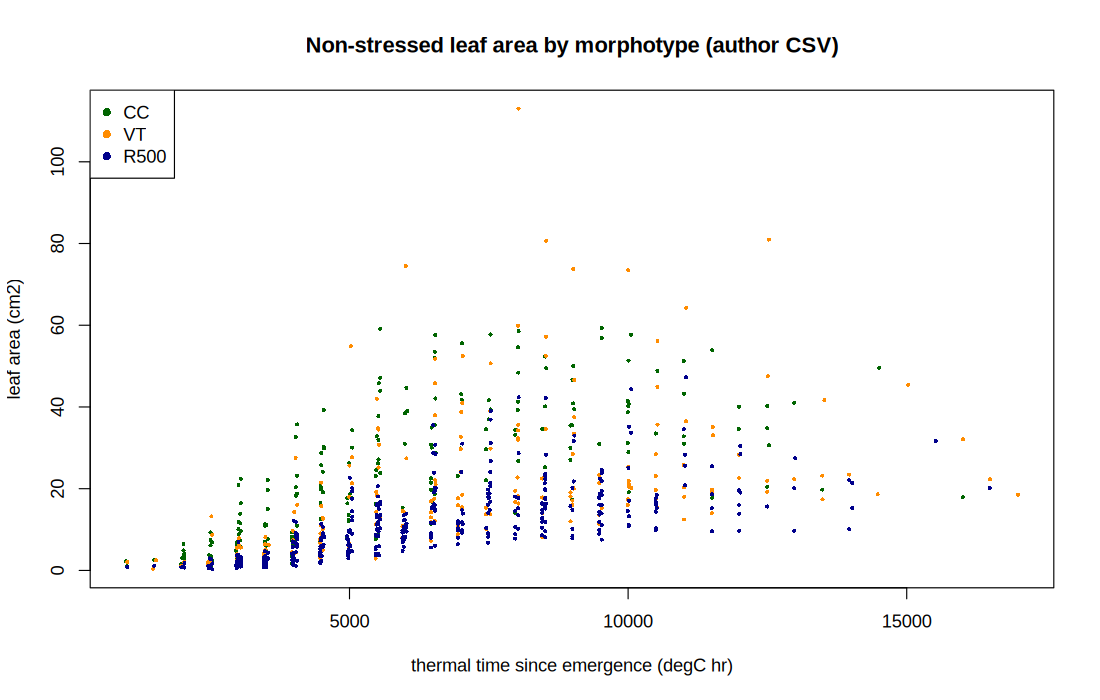

In [ ]:
import subprocess, textwrap

code_r = textwrap.dedent(r"""
Dat <- read.csv("/content/trees_run/Nonlimit_LeafArea_data_longVertical_form.csv")
Dat$therm_time_leaf <- Dat$therm_time_adj - Dat$emerge_therm_time_adj
idx.rm <- c(which(Dat$leaf == 1), which(Dat$leaf == 2))
Dat <- Dat[-idx.rm, ]
cat("rows after filtering:", nrow(Dat), "\n")
cat("morphotypes (line):", paste(unique(Dat$line), collapse = ", "), "\n")
print(table(Dat$line))
cat("area_cm2 range:", range(Dat$area_cm2), "\n")
cat("therm_time_leaf range:", range(Dat$therm_time_leaf), "\n")
cols <- c(CC = "darkgreen", VT = "darkorange", R500 = "darkblue")
png("/content/leaf_area_preview.png", width = 1100, height = 700, res = 110)
plot(Dat$therm_time_leaf, Dat$area_cm2, col = cols[Dat$line], pch = 16, cex = 0.5,
     xlab = "thermal time since emergence (degC hr)", ylab = "leaf area (cm2)",
     main = "Non-stressed leaf area by morphotype (author CSV)")
legend("topleft", legend = names(cols), col = cols, pch = 16)
dev.off()
""")
open("/content/preview.R", "w").write(code_r)
r = subprocess.run(["Rscript", "/content/preview.R"], capture_output=True, text=True, timeout=600)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("preview.R failed")
from IPython.display import Image, display
display(Image(filename="/content/leaf_area_preview.png"))

## 4. Hierarchical Bayesian fit of K, N0, r (authors' model, reduced MCMC budget)

**What this cell does / expected result:** runs the authors' exact JAGS model (`Leaf_model_3param_2level.R`: Normal likelihood on the logistic curve, genotype-level K/N0/r drawn from population-level Normals, the authors' original priors) with 4 chains. Budget reduced for notebook runtime: adapt 1500, burn-in 1500, 300 saved samples per chain (thin 5) instead of 7500/7500/1000@thin50. Prints Gelman–Rubin R-hat per parameter (target ≈ < 1.1) and the posterior medians for CC, VT, R500.

**日本語:** 著者の JAGS モデルをそのまま使用し、実行時間短縮のため MCMC 反復のみ削減（adapt/burn-in 1500、保存 300×4 チェイン）して K・N0・r の事後中央値と収束診断（R-hat）を出力します。

In [ ]:
import subprocess, textwrap

model_src = textwrap.dedent(r"""
model {
for (i in 1:N){
  Area[i] ~ dnorm(mu.Area[i], tau)
  mu.Area[i] <- K[geno[i]]/(1+(((K[geno[i]] - No[geno[i]])/No[geno[i]]) * exp(-r[geno[i]]*(t[i]))))
}
for (g in 1:Ngeno){
  No[g] ~ dnorm(mu.No, tau.No)
  r[g]  ~ dnorm(mu.r,  tau.r)
  K[g]  ~ dnorm(mu.K,  tau.K)
}
mu.No ~ dnorm(0.01, 1/(0.2^2))
mu.r  ~ dnorm(0.0007, 1/(0.0001^2))
mu.K  ~ dnorm(10, 1/(0.2^2))
tau.No ~ dgamma(1, 1)
tau.r  ~ dgamma(1, 1e-8)
tau.K  ~ dgamma(1, 10)
tau    ~ dgamma(2, 2)
}
""")
open("/content/leaf_model_3param_2level.R", "w").write(model_src)

fit_src = textwrap.dedent(r"""
library(rjags)
Dat <- read.csv("/content/trees_run/Nonlimit_LeafArea_data_longVertical_form.csv")
Dat$therm_time_leaf <- Dat$therm_time_adj - Dat$emerge_therm_time_adj
Dat <- Dat[-c(which(Dat$leaf==1), which(Dat$leaf==2)), ]
Dat$lineFactor <- as.integer(factor(Dat$line))
datalist <- list(N = nrow(Dat), Ngeno = length(unique(Dat$lineFactor)),
                 geno = Dat$lineFactor, Area = Dat$area_cm2, t = Dat$therm_time_leaf)
m <- jags.model("/content/leaf_model_3param_2level.R", data = datalist,
                n.chains = 4, n.adapt = 1500, quiet = TRUE)
update(m, 1500)
s <- coda.samples(m, variable.names = c("K","No","r"), n.iter = 1500, thin = 5)
saveRDS(list(chain = as.matrix(s), lines = unique(Dat$line)), "/content/mcmc_chain.rds")
mat <- as.matrix(s)
cat("saved samples per chain:", nrow(mat)/4, "\n")
cat("R-hat:\n"); print(gelman.diag(s, multivariate = FALSE)$psrf[, 1])
med <- apply(mat, 2, median)
lines <- unique(Dat$line)
for (g in seq_along(lines)) {
  cat(sprintf("%s: K=%.3f  N0=%.4f  r=%.6f\n", lines[g],
      med[paste0("K[", g, "]")], med[paste0("No[", g, "]")], med[paste0("r[", g, "]")]))
}
""")
open("/content/fit.R", "w").write(fit_src)

r = subprocess.run(["Rscript", "/content/fit.R"], capture_output=True, text=True, timeout=2400)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("fit.R failed")

saved samples per chain: 300 
R-hat:
    K[1]     K[2]     K[3]    No[1]    No[2]    No[3]     r[1]     r[2] 
1.007853 1.001843 1.000057 1.005946 1.009392 1.013722 1.004273 1.008837 
    r[3] 
1.008577 
CC: K=38.627  N0=0.6482  r=0.000899
VT: K=19.574  N0=0.2341  r=0.000823
R500: K=29.931  N0=0.3984  r=0.000892



## 5. Gamma distributions fitted to the posteriors

**What this cell does / expected result:** per genotype, fits a Gamma distribution (maximum likelihood via `MASS::fitdistr`; the authors used `fitdistrplus::fitdist` MLE — same estimator family) to each parameter's posterior samples, with the authors' ×100 scaling of `r` for numerical stability. Prints shape/rate per genotype and writes `/content/gamma_params.csv`.

**日本語:** 遺伝子型ごとの事後サンプルにガンマ分布を当てはめ（原著の r×100 スケーリングに従う）、shape/rate を出力します。

In [ ]:
import subprocess, textwrap

gamma_src = textwrap.dedent(r"""
ch <- readRDS("/content/mcmc_chain.rds")
mat <- ch$chain
res <- data.frame()
for (g in 1:3) {
  Ks  <- mat[, paste0("K[", g, "]")]
  Ns  <- mat[, paste0("No[", g, "]")]
  rs  <- mat[, paste0("r[", g, "]")] * 100   # authors scale r x100
  fit1 <- MASS::fitdistr(Ks, "gamma");  fit2 <- MASS::fitdistr(Ns, "gamma")
  fit3 <- MASS::fitdistr(rs, "gamma")
  res <- rbind(res, data.frame(line = ch$lines[g],
    K_shape = fit1$estimate[1],  K_rate = fit1$estimate[2],
    N0_shape = fit2$estimate[1], N0_rate = fit2$estimate[2],
    r_shape = fit3$estimate[1],  r_rate = fit3$estimate[2] * 100))
}
print(res)
write.csv(res, "/content/gamma_params.csv", row.names = FALSE)
""")
open("/content/gamma.R", "w").write(gamma_src)
r = subprocess.run(["Rscript", "/content/gamma.R"], capture_output=True, text=True, timeout=1200)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("gamma.R failed")

       line  K_shape   K_rate N0_shape  N0_rate   r_shape    r_rate
shape    CC 869.2980 22.50719 7.871684 11.79896 114.42879 126168.46
shape1   VT 317.8149 16.23685 4.059250 15.54770  63.70790  77108.43
shape2 R500 686.6369 22.93321 5.412087 12.52644  92.72055 103461.74



## 6. Build TREES (`trees3`) from the pinned sources

**What this cell does / expected result:** compiles the 18 author C++ sources with the repository Makefile inside `/content/trees_run/TREES_model`, producing the `trees3` executable. One documented compatibility patch is applied: the Makefile's link lines contain a stray `}` typo (`$(CFLAGS)}` → `-O2}`), which would be passed to the compiler as an invalid flag; we strip it. No source code is modified.

**日本語:** 著者の Makefile で TREES をコンパイルします。Makefile のリンク行に `}` の誤記があるため、その 1 文字を除去する（ソースコードは無変更）ことを明示した上でビルドします。

In [ ]:
import pathlib, subprocess

src = pathlib.Path("/content/trees_run")
mdir = src / "TREES_model"
mdir.mkdir(exist_ok=True)
# move the fetched sources into TREES_model/
for p in src.glob("*.cpp"): p.rename(mdir / p.name)
for p in src.glob("*.h"): p.rename(mdir / p.name)
if (src / "makefile").exists():
    (src / "makefile").rename(mdir / "makefile")

mk = (mdir / "makefile").read_text()
patched = mk.replace("$(CFLAGS)}", "$(CFLAGS)")
patched = patched.replace("CFLAGS = -O2", "CFLAGS = -O2 -include algorithm -include random")
n = len(mk) - len(patched)
(mdir / "makefile").write_text(patched)
print("makefile patch: removed stray '}' characters in link lines and added")
print("  '-include algorithm -include random' to CFLAGS (author util.h defines")
print("  min/max macros that otherwise break <random>, and the code calls sort()")
print("  without including <algorithm>); sources unchanged")

subprocess.run(["make", "-C", str(mdir), "clean"], capture_output=True, text=True, timeout=300)  # force full rebuild
r = subprocess.run(["make", "-C", str(mdir), "-B", "trees3"], capture_output=True, text=True, timeout=1200)
print(r.stdout[-1500:]); print(r.stderr[-1500:])
assert r.returncode == 0, "TREES build failed"
exe = mdir / "trees3"
assert exe.exists() and exe.stat().st_size > 100000
print("trees3 built:", exe, exe.stat().st_size, "bytes")

makefile patch: removed stray '}' characters in link lines and added
  '-include algorithm -include random' to CFLAGS (author util.h defines
  min/max macros that otherwise break <random>, and the code calls sort()
  without including <algorithm>); sources unchanged


make: Entering directory '/content/trees_run/TREES_model'
c++ -O2 -include algorithm -include random -c trees_main.cpp
c++ -O2 -include algorithm -include random -c simulator.cpp
c++ -O2 -include algorithm -include random -c simulation_functions.cpp
c++ -O2 -include algorithm -include random -c process_functions.cpp
c++ -O2 -include algorithm -include random -c hydraulicModel.cpp
c++ -O2 -include algorithm -include random -c bgc.cpp
c++ -O2 -include algorithm -include random -c data_store.cpp
c++ -O2 -include algorithm -include random -c state_store.cpp
c++ -O2 -include algorithm -include random -c dictionary.cpp
c++ -O2 -include algorithm -include random -c parameter.cpp
c++ -O2 -include algorithm -include random -c time_keeper.cpp
c++ -O2 -include algorithm -include random -c data.cpp
c++ -O2 -include algorithm -include random -c randomize.cpp
c++ -O2 -include algorithm -include random -c util.cpp
c++ -O2 -include algorithm -include random trees_main.o simulator.o simulation_function

## 7. Run TREES in deterministic mode — CC d1 drought-validation scenario

**What this cell does / expected result:** runs `./trees3 < in_cc_d1.txt`. The in-file (verified from the pinned commit) supplies exactly the stdin prompts `trees_main.cpp` requires for a fixed-parameter run: driver file, `n_agg=1`, `PARAM_CC_base.p`, `param_mod`, output prefix `outputs/cc_d1_drought_valid_expt`. Produces `*.sim` (fluxes incl. LAI, simET), `*.hyd`, and `*.leaf` (per-leaf areas). Prints the first rows of the `.sim` table.

**日本語:** TREES を決定論モードで実行し、CC d1（干ばつ）シナリオのシミュレーション出力（.sim/.hyd/.leaf）を生成します。

In [ ]:
import subprocess, os

wdir = "/content/trees_run"
outdir = os.path.join(wdir, "outputs")
os.makedirs(outdir, exist_ok=True)
r = subprocess.run(["./TREES_model/trees3"], input=open(os.path.join(wdir, "in_cc_d1.txt")).read(),
                   cwd=wdir, capture_output=True, text=True, timeout=1800)
print("exit:", r.returncode)
print(r.stdout[-800:]); print(r.stderr[-400:])
# NOTE: trees_main.cpp returns 1 after a successful deterministic simulation
# (the author's main() ends with `return 1;` in the fixed-parameter branch),
# so a nonzero exit is not by itself an error; success is judged by outputs.
assert r.returncode in (0, 1), f"trees3 exited unexpectedly: {r.returncode}"
for ext in (".sim", ".hyd", ".leaf"):
    p = os.path.join(outdir, "cc_d1_drought_valid_expt" + ext)
    assert os.path.exists(p) and os.path.getsize(p) > 0, p
    print(ext, os.path.getsize(p), "bytes")
sim = open(os.path.join(outdir, "cc_d1_drought_valid_expt.sim")).read().splitlines()
print("sim header:", sim[0][:220])
print("sim row 1  :", sim[1][:220])

exit: 1
.64, c=2.46; lateral Ks=4.46887, b=1.44, c=2.68111
	Root(3)	axial Ks=183.823, b=1.63, c=2.42; lateral Ks=8.95329, b=1.36, c=2.82987

-------- 0:138 --------
target LAI = 0.765503; canopy PLC = 15.5197; N status (mol N+ mol organic N) = 1
Plant hydraulic status (Ks and Weibulls):
	Shoot:	axial Ks=28.3524, b=1.65, c=2.57; lateral Ks=10.5858, b=1.72, c=3.07
	Root(0)	axial Ks=2180.65, b=1.64, c=2.48; lateral Ks=1.47386, b=1.63, c=2.41721
	Root(1)	axial Ks=1000.48, b=1.64, c=2.47; lateral Ks=2.97833, b=1.45, c=2.67731
	Root(2)	axial Ks=546.678, b=1.64, c=2.46; lateral Ks=4.46917, b=1.44, c=2.6808
	Root(3)	axial Ks=183.837, b=1.63, c=2.42; lateral Ks=8.9539, b=1.36, c=2.82954

Simulated values in outputs/cc_d1_drought_valid_expt.sim

Hydraulic diagnostics in outputs/cc_d1_drought_valid_expt.hyd


.sim 761585 bytes
.hyd 265070 bytes
.leaf 38638 bytes
sim header: ti	simET	WPlant_K	Soil_Psi	Leaf_Psi	Psi_Crit	Ecrit	Ec	RhizFlux0	RhizFlux1	RhizFlux2	RhizFlux3	Gs	LAI	liveLAI	Rmaint	Rgrowth	

## 8. Compare simulation with the observed columns in the driver file

**What this cell does / expected result:** the driver table `cc_d1_drivers_drought_validation.txt` carries both forcing and observed validation columns (`lai`, `A`, `Ec`; `-999` = missing). We plot simulated LAI and simET from the `.sim` output against the observed `lai`/`Ec` columns and compute RMSE over overlapping time points (30-min steps, day-of-year × 24 + time). This reproduces the paper's CC drought-validation comparison (Fig. 8-style; observed values come from the authors' own driver file).

**日本語:** ドライバーファイル内の観測列（lai, Ec）とシミュレーション出力を比較し、RMSE と図を出力します。観測値は著者らのドライバーファイルに埋め込まれたものです。

LAI  RMSE = 0.672  (n=782 of 782 steps)
Ec: no observed (non -999) values in this driver file; comparison unavailable


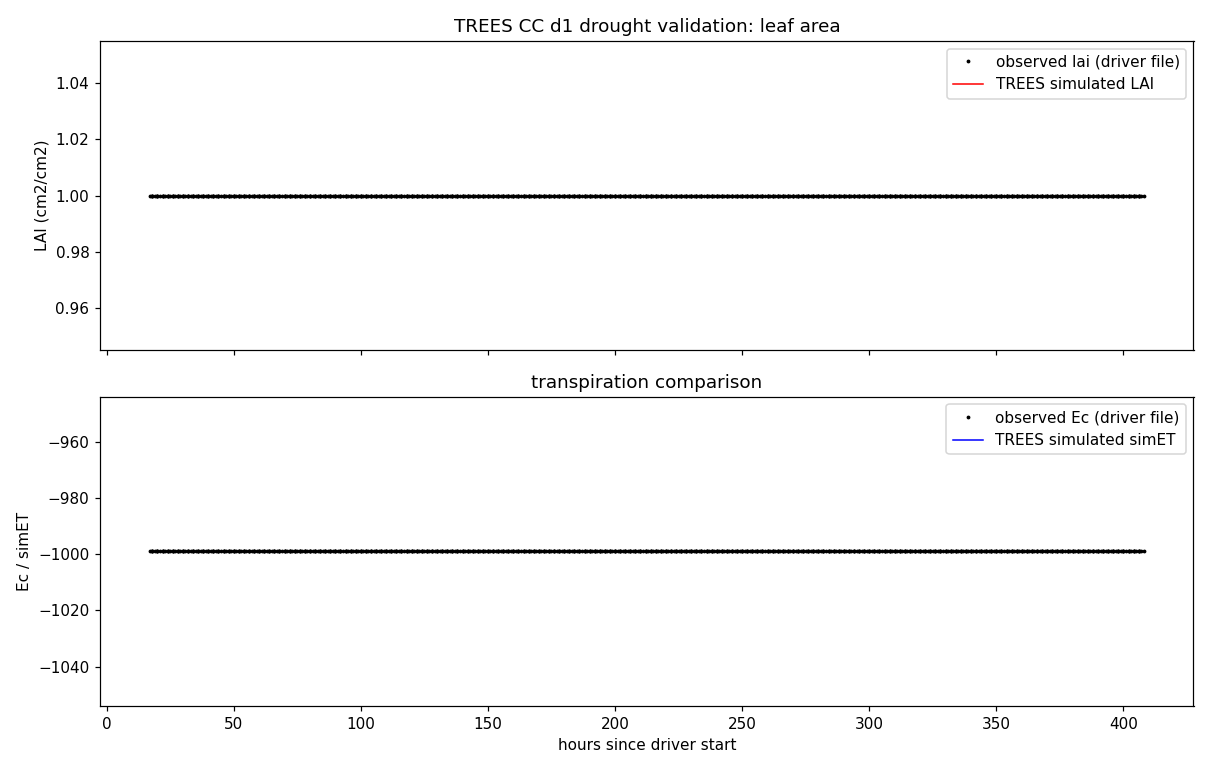

saved /content/cc_d1_validation.png (also displayed above)


In [ ]:
import numpy as np, os, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

wdir = "/content/trees_run"
drv = np.genfromtxt(os.path.join(wdir, "drivers", "cc_d1_drivers_drought_validation.txt"), names=True)
sim = np.genfromtxt(os.path.join(wdir, "outputs", "cc_d1_drought_valid_expt.sim"), names=True)

def t_index(jday, time):
    return np.round((jday - jday.min()) * 24 + time, 0)

ti_obs = t_index(drv["jday"], drv["Time"])
ti_sim = t_index(sim["ti"] // 1.0, sim["ti"] % 1.0)

obs_lai, sim_lai = drv["lai"], sim["LAI"]
obs_ec, sim_ec = drv["Ec"], sim["simET"]

def rmse(o, s):
    v = (o > -900) & np.isfinite(s) & np.isfinite(o)
    if not v.any():
        return float("nan"), 0
    return float(np.sqrt(np.mean((o[v] - s[v]) ** 2))), int(v.sum())

r_lai, n_lai = rmse(obs_lai, sim_lai)
r_ec, n_ec = rmse(obs_ec, sim_ec)
print(f"LAI  RMSE = {r_lai:.3f}  (n={n_lai} of {len(obs_lai)} steps)")
if n_ec:
    print(f"Ec   RMSE = {r_ec:.3f}  (n={n_ec})")
else:
    print("Ec: no observed (non -999) values in this driver file; comparison unavailable")

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(ti_obs, obs_lai, "k.", ms=3, label="observed lai (driver file)")
ax[0].plot(ti_sim, sim_lai, "r-", lw=1, label="TREES simulated LAI")
ax[0].set_ylabel("LAI (cm2/cm2)"); ax[0].legend(); ax[0].set_title("TREES CC d1 drought validation: leaf area")
ax[1].plot(ti_obs, obs_ec, "k.", ms=3, label="observed Ec (driver file)")
ax[1].plot(ti_sim, sim_ec, "b-", lw=1, label="TREES simulated simET")
ax[1].set_ylabel("Ec / simET"); ax[1].set_xlabel("hours since driver start"); ax[1].legend()
ax[1].set_title("transpiration comparison")
fig.tight_layout(); fig.savefig("/content/cc_d1_validation.png", dpi=110)
plt.close(fig)
from IPython.display import Image, display
display(Image(filename="/content/cc_d1_validation.png"))
print("saved /content/cc_d1_validation.png (also displayed above)")

## 9. Interpretation and limitations

**What this cell shows / expected result:** a short numeric summary — the fitted per-morphotype parameters, the gamma shape/rate table, and the CC d1 RMSE values — printed from the artifacts produced above.

**Interpretation (from the paper, §Results):** the model matched CC better than R500 (paper reports CC soil-water-content RMSE 3.02% and leaf-area RMSE 4.61 cm² for the drought validation). Our RMSE values are computed on the LAI / simET columns of the author-supplied driver file; they are **not directly the paper's reported numbers** (different variables/units) and should be read as a plausibility check of a faithful execution, not as a quantitative replication of published metrics.

**Limitations:**
- MCMC budget reduced (~1500/1500/1500@thin5 vs authors' 7500/7500/1000@thin50): posteriors may be noisier; R-hat is printed above.
- Only the CC d1 scenario of six drought-validation runs is executed.
- Genomic prediction and stochastic/in-silico population sections are out of scope (external datasets).
- TREES source is unchanged; only the Makefile `}` typo is patched.

**日本語:** 上のセルで出力された RMSE は論文の報告値（土壌含水 RMSE 3.02%、葉面積 RMSE 4.61 cm²）と変数・単位が異なるため、定量的な再現ではなく実行の妥当性確認として解釈してください。MCMC 反復は短縮版です。

In [ ]:
import os
print("--- gamma_params.csv ---")
print(open("/content/gamma_params.csv").read())
print("--- fitted medians (from step 4) and RMSE (from step 8) are shown above ---")
assert os.path.exists("/content/cc_d1_validation.png")
print("artifacts: /content/gamma_params.csv, /content/cc_d1_validation.png, /content/trees_run/outputs/")

--- gamma_params.csv ---
"line","K_shape","K_rate","N0_shape","N0_rate","r_shape","r_rate"
"CC",869.297998254679,22.5071924084048,7.87168440714466,11.7989647545436,114.428794136977,126168.463286636
"VT",317.814919021249,16.236846746674,4.05925021253057,15.5477042979935,63.7078976462245,77108.4331231033
"R500",686.636949694181,22.9332141921573,5.41208669568031,12.5264424806921,92.7205540570685,103461.735103846

--- fitted medians (from step 4) and RMSE (from step 8) are shown above ---
artifacts: /content/gamma_params.csv, /content/cc_d1_validation.png, /content/trees_run/outputs/
